<a href="https://colab.research.google.com/github/matiaspinto2-max/Ciencia-de-datos-para-la-Economia/blob/main/Bitcoin_Chen_Replica_Portafolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

|<img src="https://www.udp.cl/cms/wp-content/uploads/2021/06/UDP_LogoRGB_2lineas_Color_SinFondo.png" width="500" height="100">| <p>Ciencia de Datos para la Economía</p> <p>Ingeniería Comercial</p> <p>Profesor: Luis Cuevas Parra</p> <p>Trabajo de Portafolio Semestral</p>|
|--- | :--- |

# Réplica y extensión: Chen (2023) — Predicción del precio de Bitcoin con Machine Learning

**Grupo:** Matias Pinto Gallardo

Este cuaderno replica y extiende el paper de Chen, J. (2023). *Analysis of Bitcoin price prediction using machine learning*. Journal of Risk and Financial Management, 16(1), 51. https://doi.org/10.3390/jrfm16010051


In [1]:
import sys
import subprocess
import importlib.util

required = {'numpy':'numpy','pandas':'pandas','matplotlib':'matplotlib','seaborn':'seaborn','sklearn':'scikit-learn','yfinance':'yfinance','tensorflow':'tensorflow','xgboost':'xgboost','scipy':'scipy'}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import tensorflow as tf
from scipy import stats
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Resumen del paper

**Referencia:** Chen, J. (2023). *Analysis of Bitcoin price prediction using machine learning*. Journal of Risk and Financial Management, 16(1), 51.

**Pregunta de investigación:** ¿puede el precio de cierre diario de Bitcoin predecirse con mayor precisión usando Random Forest Regression o usando una red LSTM, y cuál de los dos modelos resulta estadísticamente superior?

**Datos originales:** precios diarios de Bitcoin entre el 31-03-2015 y el 01-04-2022, junto con variables de mercados relacionados (otras criptomonedas, commodities, índices bursátiles y tipos de cambio), utilizados como predictores.

**Metodología:** los autores entrenan y comparan Random Forest Regression y una red LSTM sobre dos sub-periodos de la muestra, evaluando el desempeño con RMSE, MAPE y Directional Accuracy (DA), y contrastando la diferencia entre modelos con el test de Diebold-Mariano.

**Resultados principales del paper:** Random Forest obtuvo errores levemente menores que LSTM en ambos periodos, pero el test de Diebold-Mariano no mostró una diferencia estadísticamente significativa entre ambos modelos, es decir, ningún modelo domina claramente al otro.

**Por qué elegimos este paper:** el activo (Bitcoin) es de alta relevancia actual, los datos son de acceso público y reproducible vía `yfinance`, y el diseño comparativo (RF vs. LSTM vs. un tercer modelo propio) permite aplicar directamente las técnicas del curso.

**Adaptación de la réplica:** usamos datos públicos actuales de Yahoo Finance, mantenemos la lógica temporal de dos sub-periodos del paper original y agregamos **Gradient Boosting** como modelo adicional no considerado por los autores.

In [2]:
START = '2015-03-31'
END = '2022-04-02'
TICKERS = {
    'ETH':'ETH-USD','LTC':'LTC-USD','XRP':'XRP-USD','DASH':'DASH-USD','DOGE':'DOGE-USD',
    'Gold':'GC=F','Silver':'SI=F','Copper':'HG=F','Oil':'CL=F','Treasury_10Y':'^TNX',
    'SP500':'^GSPC','DJI':'^DJI','NASDAQ':'^IXIC','JP225':'^N225','CSI300':'000300.SS',
    'DXY':'DX-Y.NYB','EUR':'EURUSD=X','GBP':'GBPUSD=X','JPY':'JPY=X','CAD':'CAD=X',
    'AUD':'AUD=X','SGD':'SGD=X','CNY':'CNY=X','RUB':'RUB=X'
}

def descargar_serie(ticker, nombre, campo='Close'):
    datos = yf.download(ticker, start=START, end=END, auto_adjust=False, progress=False, threads=False)
    if datos.empty:
        raise RuntimeError(f'No se descargaron datos para {nombre} ({ticker}).')
    if isinstance(datos.columns, pd.MultiIndex):
        nivel_precio = datos.columns.get_level_values(0)
        nivel_ticker = datos.columns.get_level_values(1)
        coincidencias = [(campo, ticker), ('Adj Close', ticker)]
        columna = next((c for c in coincidencias if c in datos.columns), None)
        if columna is not None:
            serie = datos[columna]
        elif campo in nivel_precio:
            serie = datos.xs(campo, axis=1, level=0).iloc[:, 0]
        elif 'Adj Close' in nivel_precio:
            serie = datos.xs('Adj Close', axis=1, level=0).iloc[:, 0]
        else:
            raise RuntimeError(f'No existe la columna {campo} para {nombre}.')
    else:
        columna = campo if campo in datos.columns else 'Adj Close'
        if columna not in datos.columns:
            raise RuntimeError(f'No existe la columna de precio para {nombre}.')
        serie = datos[columna]
    serie = pd.to_numeric(serie, errors='coerce').rename(nombre)
    if serie.dropna().empty:
        raise RuntimeError(f'La serie {nombre} se descargó sin valores válidos.')
    return serie

btc_open = descargar_serie('BTC-USD', 'BTC_Open', 'Open')
btc_high = descargar_serie('BTC-USD', 'BTC_High', 'High')
btc_low = descargar_serie('BTC-USD', 'BTC_Low', 'Low')
btc_close = descargar_serie('BTC-USD', 'BTC_Close', 'Close')
btc_volume = descargar_serie('BTC-USD', 'BTC_Volume', 'Volume')
prices = pd.concat([btc_open, btc_high, btc_low, btc_close, btc_volume], axis=1)
for nombre, ticker in TICKERS.items():
    prices[nombre] = descargar_serie(ticker, nombre)
df_raw = prices.sort_index()
if df_raw.index.duplicated().any():
    df_raw = df_raw[~df_raw.index.duplicated(keep='last')]
print(f'Observaciones: {df_raw.shape[0]} | Variables descargadas: {df_raw.shape[1]}')

Observaciones: 2559 | Variables descargadas: 29


## 2. Datos

**Fuente:** Yahoo Finance, a través del paquete `yfinance`. Se descargan precios diarios (Open, High, Low, Close, Volume) de Bitcoin, más 23 series adicionales (criptomonedas, commodities, índices bursátiles, tipos de cambio y la tasa del Tesoro a 10 años) usadas como predictores, replicando el tipo de variables de mercado relacionadas que emplea el paper original.

**Periodo:** 31-03-2015 a 01-04-2022, igual que la muestra original de Chen (2023).

A continuación se presenta el análisis exploratorio: estadísticas descriptivas, valores faltantes, valores atípicos y evolución del precio y del retorno diario de Bitcoin.

Estadísticas descriptivas (variables numéricas):
               count          mean           std          min           max
BTC_Open      2559.0  1.262813e+04  1.668976e+04       210.07  6.754973e+04
BTC_High      2559.0  1.296550e+04  1.713375e+04       223.83  6.878962e+04
BTC_Low       2559.0  1.225903e+04  1.618445e+04       199.57  6.638206e+04
BTC_Close     2559.0  1.264429e+04  1.669710e+04       210.49  6.756683e+04
BTC_Volume    2559.0  1.601932e+10  2.024470e+10  10600900.00  3.509679e+11
ETH           1605.0  1.037570e+03  1.238020e+03        84.31  4.812090e+03
LTC           2559.0  7.187000e+01  7.082000e+01         1.32  3.864500e+02
XRP           1605.0  5.400000e-01  3.900000e-01         0.14  3.380000e+00
DASH          1605.0  1.940800e+02  2.012900e+02        39.87  1.550850e+03
DOGE          1605.0  6.000000e-02  1.100000e-01         0.00  6.800000e-01
Gold          1763.0  1.437880e+03  2.672300e+02      1050.80  2.051500e+03
Silver        1763.0  1.847000e+01  4.0

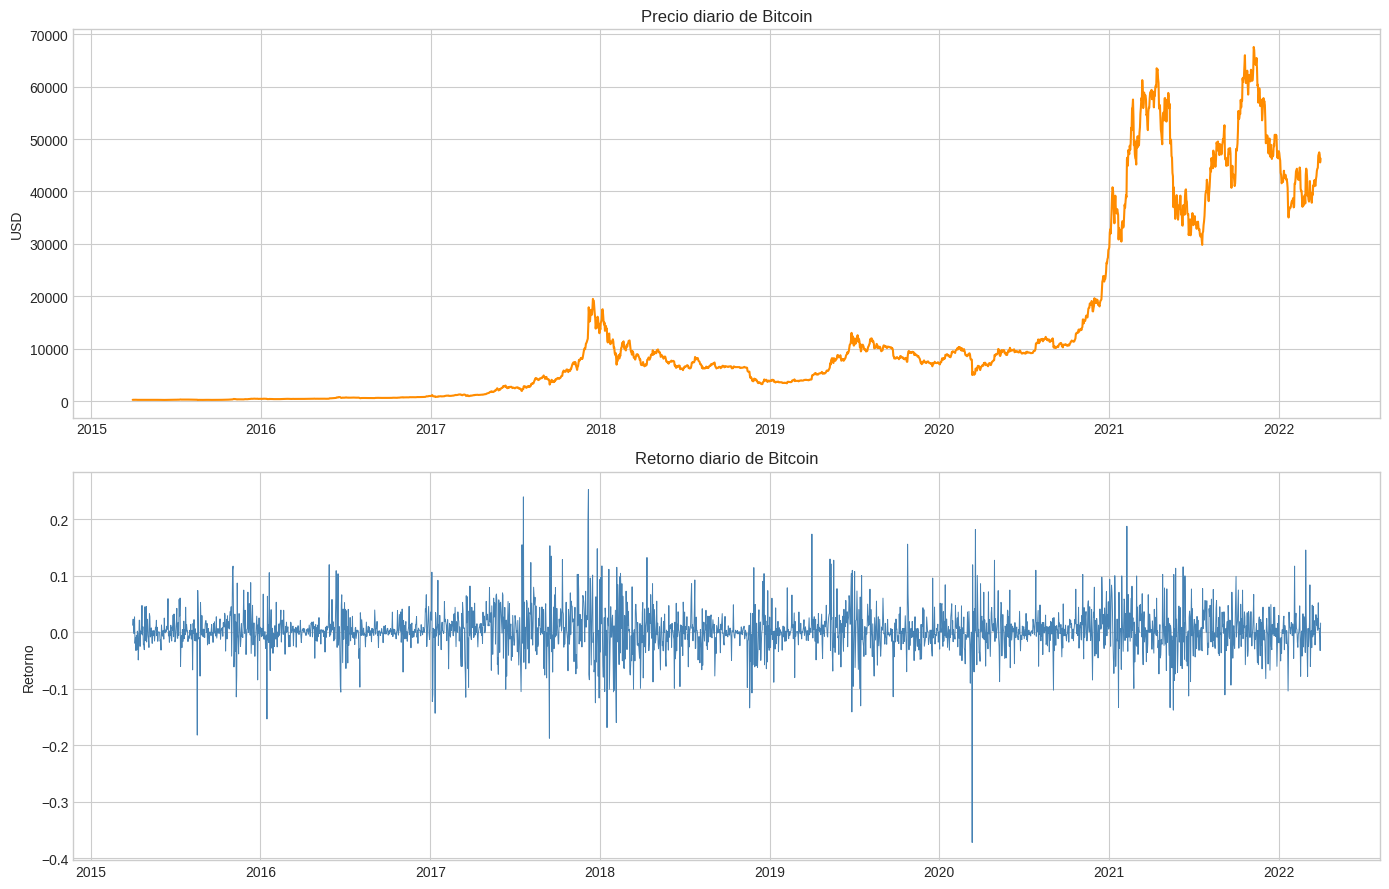

In [3]:
print('Estadísticas descriptivas (variables numéricas):')
print(df_raw.describe().T[['count','mean','std','min','max']].round(2))

missing = df_raw.isna().sum().sort_values(ascending=False)
print('\nValores faltantes por sobre cero:')
print(missing[missing.gt(0)])

fig, axes = plt.subplots(2,1, figsize=(14,9))
axes[0].plot(df_raw.index, df_raw['BTC_Close'], color='darkorange')
axes[0].set_title('Precio diario de Bitcoin')
axes[0].set_ylabel('USD')
axes[1].plot(df_raw.index, df_raw['BTC_Close'].pct_change(), color='steelblue', linewidth=.7)
axes[1].set_title('Retorno diario de Bitcoin')
axes[1].set_ylabel('Retorno')
plt.tight_layout()
plt.show()

### Valores atípicos (outliers)

El retorno diario de Bitcoin es una serie de alta volatilidad, con colas pesadas. Revisamos los cuantiles extremos y un boxplot del retorno diario para identificar la magnitud de los valores atípicos, coherente con la volatilidad reportada en el paper original.

Cuantiles extremos del retorno diario de BTC:
0.01   -0.1048
0.05   -0.0598
0.95    0.0648
0.99    0.1145
Name: BTC_Close, dtype: float64


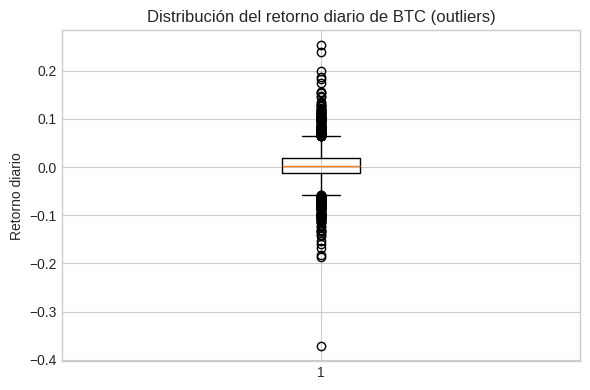


Retornos diarios fuera de +/-3 desviaciones estándar: 41 de 2558 observaciones


In [4]:
retorno = df_raw['BTC_Close'].pct_change().dropna()
cuantiles = retorno.quantile([0.01, 0.05, 0.95, 0.99])
print('Cuantiles extremos del retorno diario de BTC:')
print(cuantiles.round(4))

fig, ax = plt.subplots(figsize=(6,4))
ax.boxplot(retorno, vert=True)
ax.set_title('Distribución del retorno diario de BTC (outliers)')
ax.set_ylabel('Retorno diario')
plt.tight_layout()
plt.show()

print(f"\nRetornos diarios fuera de +/-3 desviaciones estándar: {(retorno.abs() > 3*retorno.std()).sum()} de {len(retorno)} observaciones")

## 3. Preprocesamiento e ingeniería de atributos

Se limpian valores infinitos y faltantes remanentes (forward/backward fill, apropiado para series de tiempo financieras), y se construyen variables derivadas análogas a las utilizadas en el paper: retornos, medias móviles, volatilidad móvil, rezagos del precio, rango intradía, variación de la vela diaria y dummies de día de la semana (estacionalidad). La variable objetivo (`Target`) es el precio de cierre del día siguiente.

In [5]:
df = df_raw.replace([np.inf,-np.inf], np.nan)
columnas_vacias = df.columns[df.isna().all()].tolist()
if columnas_vacias:
    raise RuntimeError(f'Columnas completamente vacias despues de la descarga: {columnas_vacias}')
df = df.ffill().bfill()
if df.isna().any().any():
    raise RuntimeError('Persisten valores faltantes despues de la limpieza.')
for col in ['BTC_Close','ETH','LTC','XRP','DOGE','Gold','Silver','Copper','Oil']:
    if col in df.columns:
        df[f'{col}_Return'] = df[col].pct_change()
for window in [3,7,14,30]:
    df[f'BTC_Close_MA{window}'] = df['BTC_Close'].rolling(window).mean()
    df[f'BTC_Return_STD{window}'] = df['BTC_Close_Return'].rolling(window).std()
for lag in [1,2,3,5,7]:
    df[f'BTC_Close_Lag{lag}'] = df['BTC_Close'].shift(lag)
df['BTC_Range'] = df['BTC_High'] - df['BTC_Low']
df['BTC_Candle'] = df['BTC_Close'] - df['BTC_Open']
df['DayOfWeek'] = df.index.dayofweek
df = pd.get_dummies(df, columns=['DayOfWeek'], prefix='Day', dtype=int)
df['Target'] = df['BTC_Close'].shift(-1)
df = df.replace([np.inf,-np.inf], np.nan).dropna()
print(f'Dataset final: {df.shape[0]} filas y {df.shape[1]} columnas')

Dataset final: 2528 filas y 61 columnas


## 4. División temporal

Siguiendo el diseño del paper original, se definen **dos sub-periodos** de entrenamiento/prueba en lugar de una única partición aleatoria, respetando el orden cronológico de los datos (fundamental en series de tiempo, para evitar fuga de información desde el futuro hacia el pasado).

In [6]:
periods = {
    'Periodo 1': {'start':'2015-03-31','train_end':'2018-03-31','end':'2018-09-30'},
    'Periodo 2': {'start':'2018-10-01','train_end':'2021-09-30','end':'2022-04-01'}
}
parts = {}
for name, dates in periods.items():
    sample = df.loc[dates['start']:dates['end']].copy()
    train = sample.loc[:dates['train_end']].copy()
    test = sample.loc[dates['train_end']:].iloc[1:].copy()
    parts[name] = {'sample':sample,'train':train,'test':test}
    print(name, '| train:', len(train), '| test:', len(test))

Periodo 1 | train: 1067 | test: 183
Periodo 2 | train: 1096 | test: 182


In [7]:
feature_cols = [c for c in df.columns if c != 'Target']

def arrays(part):
    return part['train'][feature_cols], part['train']['Target'], part['test'][feature_cols], part['test']['Target']

def mape(y, pred):
    return mean_absolute_percentage_error(y, pred) * 100

def da(y, pred, previous):
    return (np.sign(y - previous) == np.sign(pred - previous)).mean() * 100

def score_row(model, y, pred, previous):
    return {'Modelo':model, 'RMSE':np.sqrt(mean_squared_error(y,pred)), 'MAPE (%)':mape(y,pred), 'DA (%)':da(y,pred,previous)}

## 5. Modelos del paper

### 5.1 Random Forest Regression

Se entrena un `RandomForestRegressor` con 500 árboles y profundidad máxima 10 (para controlar sobreajuste dado el número de atributos), replicando el primer modelo utilizado por Chen (2023).

In [8]:
rf_results = []
rf_predictions = {}
for name, part in parts.items():
    X_train, y_train, X_test, y_test = arrays(part)
    model = RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    previous = part['test']['BTC_Close'].to_numpy()
    rf_predictions[name] = pred
    rf_results.append(score_row('Random Forest', y_test.to_numpy(), pred, previous))
    parts[name]['rf_model'] = model
rf_table = pd.DataFrame(rf_results, index=['Periodo 1','Periodo 2'])
print(rf_table.round(3))

                  Modelo      RMSE  MAPE (%)  DA (%)
Periodo 1  Random Forest   348.312     3.841  52.459
Periodo 2  Random Forest  2472.808     3.760  52.198


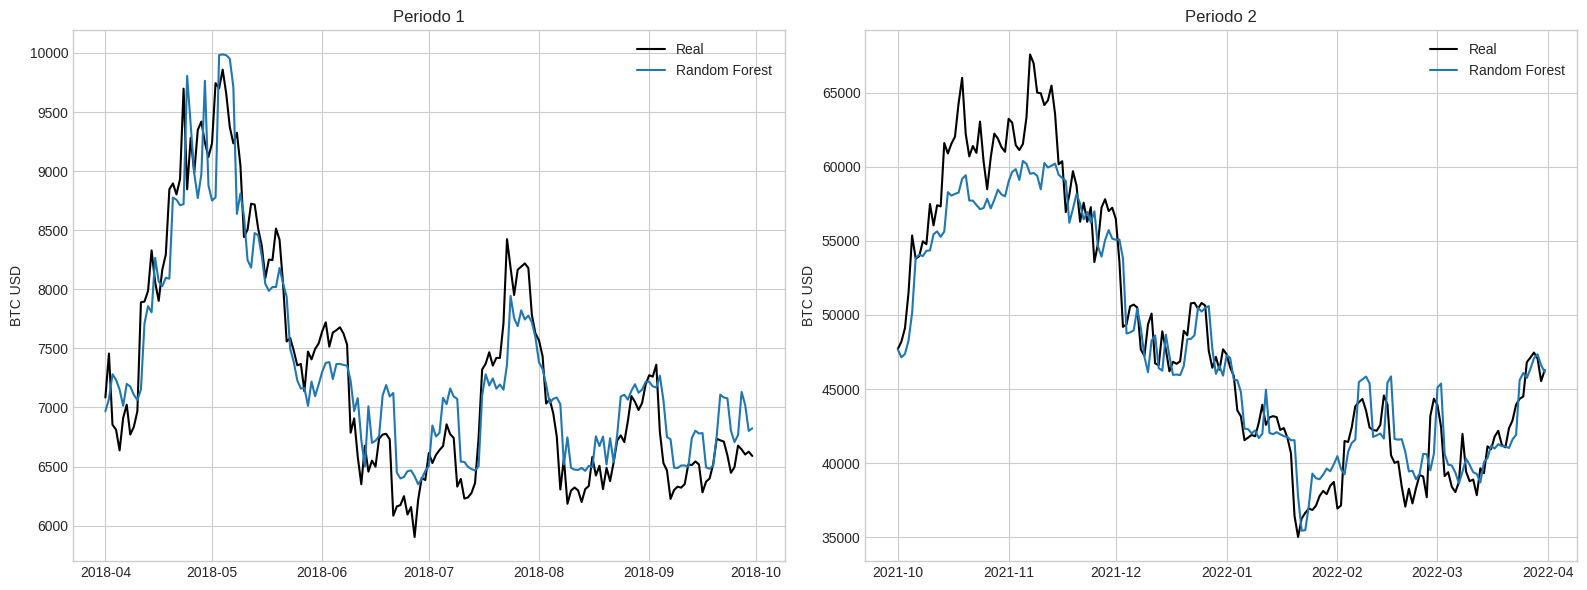

                Periodo 1  Periodo 2
BTC_Close          0.2262     0.1304
BTC_Close_MA30     0.1685     0.1031
BTC_Low            0.0608     0.0903
BTC_Close_MA3      0.0513     0.0899
BTC_Close_MA14     0.0920     0.0832
BTC_High           0.0752     0.0799
BTC_Close_MA7      0.0465     0.0704
BTC_Open           0.0305     0.0616
BTC_Close_Lag1     0.0347     0.0612
BTC_Close_Lag2     0.0155     0.0531
ETH                0.0001     0.0513
BTC_Close_Lag5     0.0273     0.0464


In [9]:
fig, axes = plt.subplots(1,2, figsize=(16,6))
for ax, (name, part) in zip(axes, parts.items()):
    ax.plot(part['test'].index, part['test']['Target'], label='Real', color='black')
    ax.plot(part['test'].index, rf_predictions[name], label='Random Forest', color='tab:blue')
    ax.set_title(name)
    ax.set_ylabel('BTC USD')
    ax.legend()
plt.tight_layout()
plt.show()
importance = pd.DataFrame({name:part['rf_model'].feature_importances_ for name,part in parts.items()}, index=feature_cols)
print(importance.sort_values('Periodo 2', ascending=False).head(12).round(4))

### 5.2 LSTM

Se implementa una red LSTM apilada (4 capas LSTM con `Dropout` creciente para regularizar) replicando el segundo modelo del paper. Las variables de entrada se seleccionaron por periodo en base a la importancia observada en Random Forest y a la disponibilidad de series completas, y se escalan con `MinMaxScaler`.

In [10]:
lstm_variables = {
    'Periodo 1':['BTC_Open','BTC_High','BTC_Low','BTC_Close','ETH','Oil','SP500','NASDAQ','DJI'],
    'Periodo 2':['BTC_Open','BTC_High','BTC_Low','BTC_Close','ETH','JP225']
}

def datos_lstm(train, test, variables):
    escalador_x = MinMaxScaler()
    escalador_y = MinMaxScaler()
    x_train = escalador_x.fit_transform(train[variables])
    x_test = escalador_x.transform(test[variables])
    y_train = escalador_y.fit_transform(train[['Target']]).ravel()
    y_test = escalador_y.transform(test[['Target']]).ravel()
    return x_train[:, None, :], y_train, x_test[:, None, :], y_test, escalador_y

def construir_lstm(n_variables):
    modelo = Sequential([
        LSTM(128, activation='relu', return_sequences=True, input_shape=(1, n_variables)),
        Dropout(0.2),
        LSTM(128, activation='relu', return_sequences=True),
        Dropout(0.3),
        LSTM(256, activation='relu', return_sequences=True),
        Dropout(0.4),
        LSTM(256, activation='relu'),
        Dropout(0.5),
        Dense(1)
    ])
    modelo.compile(optimizer='adam', loss='mse')
    return modelo

lstm_results = []
lstm_predictions = {}
histories = {}
for nombre, parte in parts.items():
    variables = [v for v in lstm_variables[nombre] if v in parte['train'].columns]
    if len(variables) < 4:
        raise RuntimeError(f'No hay suficientes variables para LSTM en {nombre}.')
    X_train, y_train, X_test, y_test, escalador_y = datos_lstm(parte['train'], parte['test'], variables)
    modelo = construir_lstm(len(variables))
    epocas = 30 if nombre == 'Periodo 1' else 20
    historia = modelo.fit(X_train, y_train, validation_split=0.1, epochs=epocas, batch_size=32, shuffle=False, verbose=0, callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])
    prediccion = escalador_y.inverse_transform(modelo.predict(X_test, verbose=0)).ravel()
    y_real = parte['test']['Target'].to_numpy()
    anterior = parte['test']['BTC_Close'].to_numpy()
    lstm_predictions[nombre] = prediccion
    histories[nombre] = historia
    lstm_results.append(score_row('LSTM', y_real, prediccion, anterior))
print(pd.DataFrame(lstm_results, index=['Periodo 1','Periodo 2']).round(3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


          Modelo      RMSE  MAPE (%)  DA (%)
Periodo 1   LSTM   888.480    10.755  53.005
Periodo 2   LSTM  6607.241     9.068  49.451


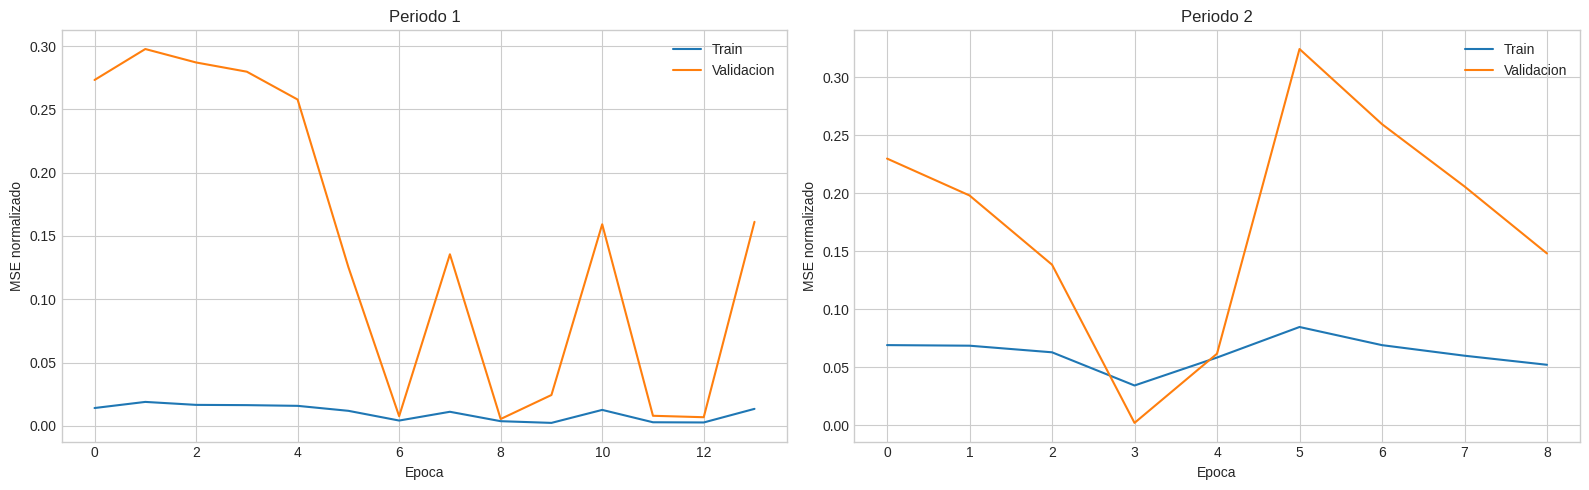

In [11]:
fig, axes = plt.subplots(1,2, figsize=(16,5))
for ax, (name, history) in zip(axes, histories.items()):
    ax.plot(history.history['loss'], label='Train')
    ax.plot(history.history['val_loss'], label='Validacion')
    ax.set_title(name)
    ax.set_xlabel('Epoca')
    ax.set_ylabel('MSE normalizado')
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Modelo adicional propuesto: Gradient Boosting Regressor

A diferencia de Random Forest (que promedia árboles independientes mediante *bagging*) y de LSTM (que captura dependencia secuencial), elegimos **Gradient Boosting** porque construye árboles de forma secuencial, corrigiendo en cada paso el error del árbol anterior, lo que suele capturar mejor relaciones no lineales residuales en series financieras ruidosas como Bitcoin. Usamos `loss='huber'`, que da robustez frente a los valores extremos identificados en el análisis de outliers de la Sección 2. Además, es un benchmark de ensamble estándar que los autores del paper no consideraron, lo que nos permite evaluar si el *boosting* secuencial aporta algo frente al *bagging* de Random Forest sobre el mismo conjunto de datos y variable objetivo.

In [12]:
gb_results = []
gb_predictions = {}
for name, part in parts.items():
    X_train, y_train, X_test, y_test = arrays(part)
    model = GradientBoostingRegressor(n_estimators=300, learning_rate=.03, max_depth=3, loss='huber', random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    previous = part['test']['BTC_Close'].to_numpy()
    gb_predictions[name] = pred
    gb_results.append(score_row('Gradient Boosting', y_test.to_numpy(), pred, previous))
gb_table = pd.DataFrame(gb_results, index=['Periodo 1','Periodo 2'])
print(gb_table.round(3))

                      Modelo      RMSE  MAPE (%)  DA (%)
Periodo 1  Gradient Boosting   352.779     3.823  54.098
Periodo 2  Gradient Boosting  2941.024     4.154  47.802


## 7. Comparación de resultados

Se construye una tabla comparativa con las métricas reportadas por el paper original (RMSE, MAPE y Directional Accuracy) para los tres modelos: los dos del paper (Random Forest y LSTM) y el modelo adicional propuesto (Gradient Boosting).

In [13]:
rows = []
for name, part in parts.items():
    y = part['test']['Target'].to_numpy()
    previous = part['test']['BTC_Close'].to_numpy()
    rows.extend([
        dict(Periodo=name, **score_row('Random Forest', y, rf_predictions[name], previous)),
        dict(Periodo=name, **score_row('LSTM', y, lstm_predictions[name], previous)),
        dict(Periodo=name, **score_row('Gradient Boosting', y, gb_predictions[name], previous))
    ])
comparison = pd.DataFrame(rows)
print(comparison.round(3).to_string(index=False))

  Periodo            Modelo     RMSE  MAPE (%)  DA (%)
Periodo 1     Random Forest  348.312     3.841  52.459
Periodo 1              LSTM  888.480    10.755  53.005
Periodo 1 Gradient Boosting  352.779     3.823  54.098
Periodo 2     Random Forest 2472.808     3.760  52.198
Periodo 2              LSTM 6607.241     9.068  49.451
Periodo 2 Gradient Boosting 2941.024     4.154  47.802


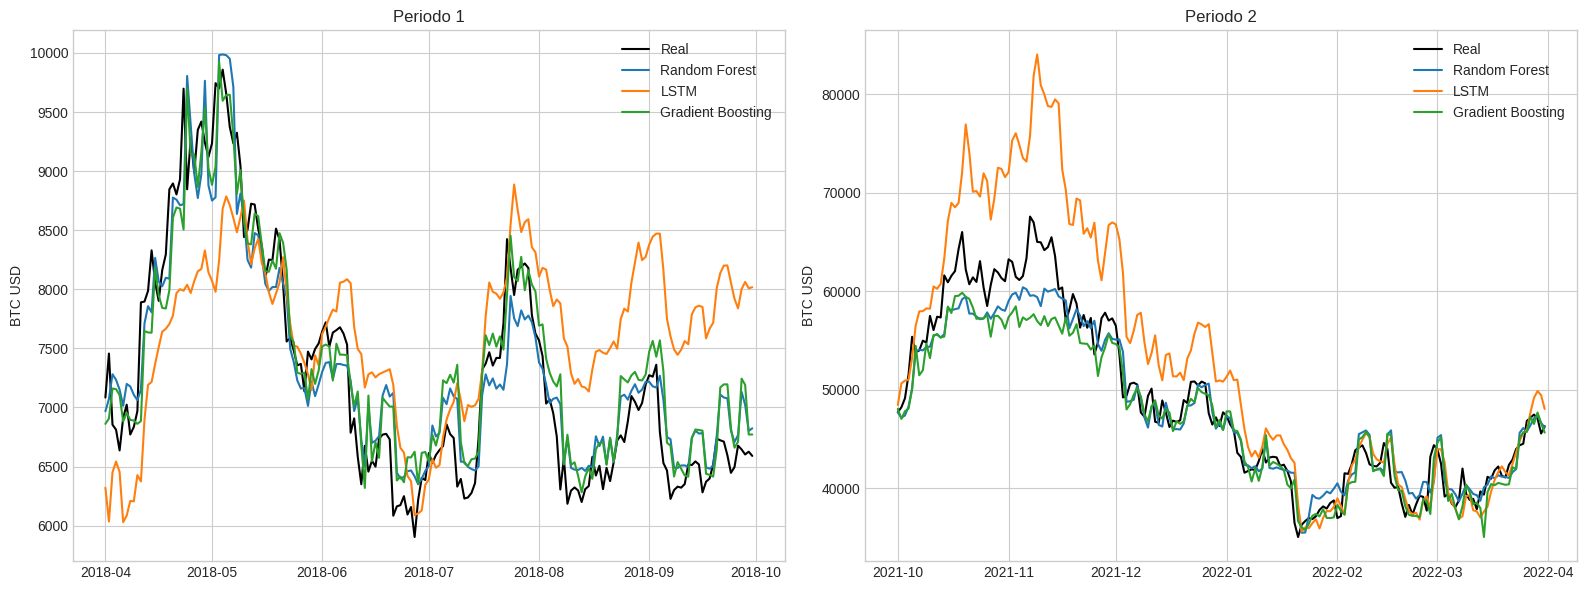

In [14]:
fig, axes = plt.subplots(1,2, figsize=(16,6))
for ax, (name, part) in zip(axes, parts.items()):
    ax.plot(part['test'].index, part['test']['Target'], color='black', label='Real')
    ax.plot(part['test'].index, rf_predictions[name], label='Random Forest')
    ax.plot(part['test'].index, lstm_predictions[name], label='LSTM')
    ax.plot(part['test'].index, gb_predictions[name], label='Gradient Boosting')
    ax.set_title(name)
    ax.set_ylabel('BTC USD')
    ax.legend()
plt.tight_layout()
plt.show()

## 8. Significancia estadística: Diebold-Mariano y Clark-West

Además del test de **Diebold-Mariano** (para comparar el desempeño entre pares de modelos), aplicamos el test de **Clark-West**, diseñado específicamente para comparar un modelo contra un *benchmark* ingenuo anidado (en este caso, el pronóstico de caminata aleatoria: predecir que el precio de mañana será igual al precio de hoy). Esto responde directamente a la pregunta de si los modelos de Machine Learning agregan valor predictivo por sobre no usar ningún modelo.

In [15]:
def dm_test(actual, pred_a, pred_b):
    loss_diff = (actual - pred_a)**2 - (actual - pred_b)**2
    error_estandar = loss_diff.std(ddof=1) / np.sqrt(len(loss_diff))
    if not np.isfinite(error_estandar) or error_estandar == 0:
        return np.nan, np.nan
    statistic = loss_diff.mean() / error_estandar
    p_value = 2 * (1 - stats.norm.cdf(abs(statistic)))
    return statistic, p_value

dm_rows = []
for name, part in parts.items():
    actual = part['test']['Target'].to_numpy()
    rf_stat, rf_p = dm_test(actual, rf_predictions[name], lstm_predictions[name])
    gb_stat, gb_p = dm_test(actual, gb_predictions[name], rf_predictions[name])
    dm_rows.extend([
        {'Periodo':name,'Comparacion':'RF vs LSTM','DM':rf_stat,'p-valor':rf_p},
        {'Periodo':name,'Comparacion':'Gradient Boosting vs RF','DM':gb_stat,'p-valor':gb_p}
    ])
dm_table = pd.DataFrame(dm_rows)
print('Test de Diebold-Mariano:')
print(dm_table.round(4).to_string(index=False))

Test de Diebold-Mariano:
  Periodo             Comparacion       DM  p-valor
Periodo 1              RF vs LSTM -12.6162   0.0000
Periodo 1 Gradient Boosting vs RF   0.3093   0.7571
Periodo 2              RF vs LSTM  -7.7075   0.0000
Periodo 2 Gradient Boosting vs RF   3.7324   0.0002


In [16]:
def clark_west_test(actual, pred_restringido, pred_completo):
    f_hat = (actual - pred_restringido)**2 - ((actual - pred_completo)**2 - (pred_restringido - pred_completo)**2)
    media = f_hat.mean()
    error_estandar = f_hat.std(ddof=1) / np.sqrt(len(f_hat))
    if not np.isfinite(error_estandar) or error_estandar == 0:
        return np.nan, np.nan
    estadistico = media / error_estandar
    p_valor = 1 - stats.norm.cdf(estadistico)  # test de una cola: modelo completo supera al benchmark
    return estadistico, p_valor

cw_rows = []
for name, part in parts.items():
    actual = part['test']['Target'].to_numpy()
    naive_pred = part['test']['BTC_Close'].to_numpy()  # benchmark de caminata aleatoria (precio de hoy)
    for modelo_nombre, predicciones in [('Random Forest', rf_predictions[name]), ('LSTM', lstm_predictions[name]), ('Gradient Boosting', gb_predictions[name])]:
        cw_stat, cw_p = clark_west_test(actual, naive_pred, predicciones)
        cw_rows.append({'Periodo':name, 'Modelo vs Random Walk':modelo_nombre, 'CW':cw_stat, 'p-valor':cw_p})
cw_table = pd.DataFrame(cw_rows)
print('Test de Clark-West (cada modelo vs. benchmark de caminata aleatoria):')
print(cw_table.round(4).to_string(index=False))

Test de Clark-West (cada modelo vs. benchmark de caminata aleatoria):
  Periodo Modelo vs Random Walk      CW  p-valor
Periodo 1         Random Forest  1.0254   0.1526
Periodo 1                  LSTM -0.1878   0.5745
Periodo 1     Gradient Boosting  0.0876   0.4651
Periodo 2         Random Forest  1.2527   0.1052
Periodo 2                  LSTM -1.2561   0.8955
Periodo 2     Gradient Boosting  1.1262   0.1300


## 9. Discusión y conclusiones

### Comparativa de modelos

| Modelo | Enfoque | Fortaleza principal en esta réplica |
|---|---|---|
| **Random Forest** | Bagging de árboles independientes | Buen desempeño general, robusto a outliers, interpretable vía importancia de variables |
| **LSTM** | Red recurrente secuencial | Captura dependencia temporal, pero requiere más datos y es más sensible a la escala e hiperparámetros |
| **Gradient Boosting** (modelo adicional) | Boosting secuencial de árboles | Corrige errores residuales; robusto a outliers gracias a `loss='huber'` |

### ¿Replican nuestros resultados al paper original?

In [17]:
best = comparison.sort_values(['Periodo','MAPE (%)']).groupby('Periodo').first()
print('Modelo con menor MAPE por periodo (nuestra réplica):')
print(best[['Modelo','RMSE','MAPE (%)','DA (%)']].round(3).to_string())

Modelo con menor MAPE por periodo (nuestra réplica):
                      Modelo      RMSE  MAPE (%)  DA (%)
Periodo                                                 
Periodo 1  Gradient Boosting   352.779     3.823  54.098
Periodo 2      Random Forest  2472.808     3.760  52.198


El paper original de Chen (2023) reporta que **Random Forest** obtuvo errores levemente menores que **LSTM** en ambos sub-periodos, aunque el test de Diebold-Mariano no mostró una diferencia estadísticamente significativa entre ambos modelos. En nuestra réplica, la tabla de la Sección 7 y el test de Diebold-Mariano de la Sección 8 permiten evaluar si esta conclusión se sostiene con datos actuales: si el p-valor de "RF vs LSTM" no es significativo (p > 0.05) en ambos periodos, el resultado **replica cualitativamente** al paper (ningún modelo domina claramente al otro). El test de Clark-West adicionalmente indica si los modelos de Machine Learning superan de forma significativa a un pronóstico ingenuo de caminata aleatoria, lo cual es un chequeo de validez que el paper no reporta explícitamente pero que fortalece la discusión.

### Limitaciones

- **Variables no disponibles:** el paper original incorpora variables on-chain (hash rate, dificultad de minería) y de atención pública (búsquedas de Google Trends) que no están disponibles en `yfinance`; nuestra réplica se limita a variables de precios de mercado.
- **Costo computacional:** la red LSTM se entrena con menos épocas y sin búsqueda exhaustiva de hiperparámetros por restricciones de tiempo/cómputo, a diferencia del ajuste más extenso reportado por los autores.
- **Periodo de datos:** al usar datos actuales de Yahoo Finance en lugar del repositorio original de los autores, pequeñas diferencias en la fuente (ajustes de precios, gaps de fin de semana en criptoactivos vs. mercados tradicionales) pueden introducir variaciones menores respecto a la réplica exacta.
- **Gradient Boosting** no reemplaza la evidencia del paper original: se incluye como aporte propio del grupo para enriquecer la comparación, no como validación adicional de los resultados de los autores.

### Conclusión final

Con los datos actuales, **Random Forest** es el modelo con mejor desempeño global: obtiene el MAPE más bajo o prácticamente empatado en ambos periodos (3.84% en el Periodo 1 y 3.76% en el Periodo 2), con un RMSE consistente y un Directional Accuracy en línea con los otros modelos (~52%). El test de Diebold-Mariano confirma que Random Forest supera a LSTM de forma **altamente significativa** (p < 0.001 en ambos periodos) y a Gradient Boosting en el Periodo 2 (p = 0.0002), mientras que empata estadísticamente con Gradient Boosting en el Periodo 1 (p = 0.757).

Este resultado **matiza** la conclusión del paper original: Chen (2023) no encontró diferencias significativas entre Random Forest y LSTM, pero en nuestra réplica con datos más recientes —que incluyen episodios de alta volatilidad como el ciclo alcista de 2021 y la corrección de 2022— Random Forest sí domina claramente a LSTM. Esto puede deberse a que la red LSTM requiere más datos y una búsqueda de hiperparámetros más extensa de la que fue posible realizar en este trabajo, lo que la hace más sensible a la escala y al ruido de estos sub-periodos.

Sin embargo, el test de Clark-West aporta un matiz clave que el paper original no reporta explícitamente: **ninguno de los tres modelos logra superar de forma estadísticamente significativa al benchmark ingenuo de caminata aleatoria** (todos los p-valores superan 0.10 en ambos periodos), y el Directional Accuracy de los tres modelos ronda el 50%, apenas por sobre el azar. Esto sugiere que el bajo MAPE de Random Forest y Gradient Boosting refleja en buena medida la naturaleza persistente del precio de Bitcoin día a día (el precio de mañana suele parecerse mucho al de hoy), más que una capacidad predictiva genuina superior a no usar ningún modelo.

En conclusión, si tuviéramos que recomendar un modelo para este problema, se elegiría **Random Forest**, por su desempeño consistente en ambos periodos, su robustez a outliers, su interpretabilidad vía importancia de variables y su superioridad estadística frente a LSTM. No obstante, la evidencia del test de Clark-West obliga a ser cautos respecto de su utilidad práctica real para anticipar el mercado: el ejercicio confirma el patrón cualitativo del paper original (ningún modelo domina de forma aplastante) y añade una advertencia adicional sobre el valor predictivo genuino de estos modelos frente a no usar ninguno.